In [1]:
#required packages. Make sure all these are installed in your prefered working environment. I can show you how to do this 
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import scipy.stats

import seaborn as sns

import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statannot import add_stat_annotation

In [2]:
tpm_int=pd.read_csv("Intestine/salmon.merged.gene_tpm_intestine.tsv",index_col=0,sep="\t")
tpm_int=tpm_int.T
tpm_int = tpm_int[tpm_int.gt(tpm_int["ENSDARG00000109337"],0)]
tpm_int=tpm_int.dropna(axis='columns')
tpm_int=tpm_int.T
tpm_int["old asgr ave"]=(tpm_int["c830_int_1"]+tpm_int["c830_int_2"]+tpm_int["c830_int_3"]+tpm_int["c865_int_1"]+tpm_int["c865_int_2"])/5
tpm_int["new asgr ave"]=(tpm_int["c830_int_4"]+tpm_int["c830_int_5"]+tpm_int["c865_int_4"]+tpm_int["c865_int_3"])/4
tpm_int["old nluc"]=(tpm_int["control_int_1"]+tpm_int["control_int_2"])/2
tpm_int["new nluc"]=(tpm_int["control_int_3"]+tpm_int["control_int_4"])/2
tpm_int["fold old"]=tpm_int["old asgr ave"]/tpm_int["old nluc"]
tpm_int["fold new"]=tpm_int["new asgr ave"]/tpm_int["new nluc"]
tpm_int['fold old'] = pd.to_numeric(tpm_int['fold old'], errors='coerce')
tpm_int['fold new'] = pd.to_numeric(tpm_int['fold new'], errors='coerce')

In [3]:
tpm_int[tpm_int.gene_name=="ldlra"]

,gene_name,c830_int_1,c830_int_2,c830_int_3,c830_int_4,c830_int_5,c865_int_1,c865_int_2,c865_int_3,c865_int_4,control_int_1,control_int_2,control_int_3,control_int_4,old asgr ave,new asgr ave,old nluc,new nluc,fold old,fold new
gene_id,,,,,,,,,,,,,,,,,,,,


In [24]:
tpm_int.nlargest(20,"fold new")

,gene_name,c830_int_1,c830_int_2,c830_int_3,c830_int_4,c830_int_5,c865_int_1,c865_int_2,c865_int_3,c865_int_4,control_int_1,control_int_2,control_int_3,control_int_4,old asgr ave,new asgr ave,old nluc,new nluc,fold old,fold new
gene_id,,,,,,,,,,,,,,,,,,,,
ENSDARG00000040282,zgc:92590,1622.934771,2243.677299,1060.136834,224.641685,711.136374,1150.777308,2.676768,0.456717,123.542303,1364.544339,2456.168246,0.377152,0.301731,1216.040596,264.94427,1910.356293,0.339442,0.636552,780.529987
ENSDARG00000097789,pon3.2,35.667882,41.907451,42.744902,36.785819,36.246332,60.718346,5.12574,1.860829,33.225476,40.016908,42.780595,0.827491,0.606232,37.232864,27.029614,41.398752,0.716862,0.899372,37.705490
ENSDARG00000058966,zgc:112332,5.668368,2.832977,1.764072,10.585992,4.793213,0.678751,0.585589,0.436836,0.361298,6.57059,2.974577,0.207417,0.114083,2.305951,4.044335,4.772583,0.16075,0.483166,25.159159
ENSDARG00000095939,si:ch73-226l13.2,4.055761,2.383,2.288081,22.551626,79.130555,3.08379,2.236764,42.468269,78.134439,3.166571,2.727554,2.60685,3.307008,2.809479,55.571222,2.947062,2.956929,0.953315,18.793560
ENSDARG00000088885,si:ch1073-340i21.3,1.167816,1.149164,0.489457,1.822243,0.520679,5.265655,3.098435,2.272518,3.109658,0.17105,0.953814,0.236579,0.026025,2.234105,1.931275,0.562432,0.131302,3.972223,14.708645
ENSDARG00000078433,spc25,1.435698,1.378136,1.634348,2.099658,3.794515,1.606508,1.435831,2.598873,4.485543,1.902172,3.589296,0.513229,0.129483,1.498104,3.244647,2.745734,0.321356,0.545612,10.096738
ENSDARG00000052721,prim2,33.87532,33.280448,23.751086,15.085788,15.233269,1.412377,2.748311,1.823705,0.754641,2.820434,3.200985,1.271744,0.384848,19.013508,8.224351,3.010709,0.828296,6.315292,9.929241
ENSDARG00000052497,slc23a4,5.08801,6.522057,4.624746,2.884751,5.239844,4.287007,6.416689,7.534077,9.975297,4.693268,8.587571,1.088661,0.25742,5.387702,6.408492,6.64042,0.673041,0.811350,9.521704
ENSDARG00000017710,ppp1r14ab,5.421481,3.390126,2.488377,1.355142,3.528002,2.717517,5.051291,3.866462,4.237426,1.852117,2.497434,0.597198,0.138303,3.813758,3.246758,2.174775,0.36775,1.753633,8.828698


In [5]:
#import Deseq2 output and remove genes with no pvalue 
pooled_results=pd.read_csv("6_3_2024_analysis/padj_stats_6_3_2024.csv",index_col=0)
pooled_results=pooled_results.replace('', 0)
pooled_results=pooled_results.dropna()
pooled_results.loc['pvalue']

KeyError: 'pvalue'

In [6]:
#genes that I want to label on the plot 
upregulated=("stard10","prdx1","cd7al","PDK2","hsd17b12a","sst1.1","sst2",'hmgn3')
downregulated=("ldlra","lipg","apoea","cyp7a1","mfsd2ab",'ldlra')
#left volcano plot (upregulated). Thresholds: 0.05 pvalue, 1.5 lfc
bioinfokit.visuz.GeneExpression.volcano(df=pooled_results, lfc="log2FoldChange",lfc_thr=(1.5, 1.5), pv_thr=(0.05, 0.05), pv="pvalue",figname="asgr mutants vs. nanoluc",r=1000, geneid="gene_name", genenames=downregulated,
    show=True,gstyle=1,gfont=10,dim=(10,13),sign_line=True,xlm=(-8,0,1),ylm=(-1,13,1))

NameError: name 'bioinfokit' is not defined

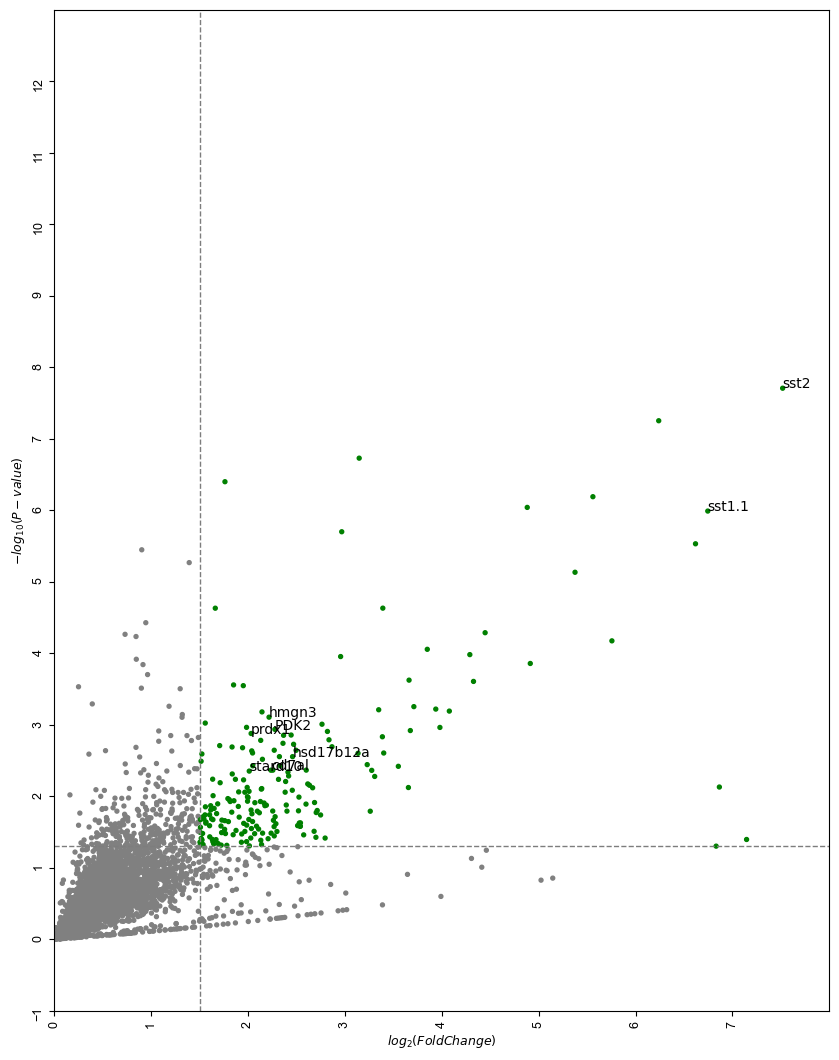

In [57]:
#right volcano plot (upregulated). Thresholds: 0.05 pvalue, 1.5 lfc 
bioinfokit.visuz.GeneExpression.volcano(df=pooled_results, lfc="log2FoldChange",lfc_thr=(1.5, 1.5), pv_thr=(0.05, 0.05), pv="pvalue",figname="asgr mutants vs. nanoluc",r=1000, geneid="gene_name", genenames=upregulated,
    show=True,gstyle=1,gfont=10,dim=(10,13),sign_line=True,xlm=(0,8,1),ylm=(-1,13,1))

# Generating Bar Graph of Significant Genes via RNA-seq analysis

In [7]:
#imports tpm 
significant_counts=pd.read_csv('5_24_24_newdata/salmon.merged.gene_counts.tsv',sep="\t", index_col=1).T

In [8]:
#removes gene id (keeps only name and transposes matrix )
significant_counts=significant_counts.tail(-1)
significant_counts=significant_counts.T


In [9]:
#Beginning to process things for PCA. Imports tpm and transposes the matrix, removing the first (gene_id row)
tpm=pd.read_csv("6_3_2024_analysis/salmon.merged.gene_tpm_6_3_24.tsv",index_col=1,sep='\t').T
tpm=tpm.drop(["asgr1a_c830_5_dif","asgr1a_c830_6_dif","asgr1a_c830_7_dif",
                         "asgr1a_c865_7_dif","asgr1a_c865_8_dif","asgr1a_c865_9_dif",
                         "nluc_control_7_dif","nluc_control_8_dif","nluc_control_9_dif"])
tpm=tpm.iloc[1:,]
tpm

FileNotFoundError: [Errno 2] No such file or directory: '6_3_2024_analysis/salmon.merged.gene_tpm_6_3_24.tsv'

In [4]:
#make sure each read is a float
tpm=tpm.astype(float)
#add two columns to cluster samples for PCA 
tpm["Genotype"]=["c830","c830","c830","c830","c865","c865","c865","c865","c865","WT","WT","WT","WT","WT"]
tpm["Replicate"]=[1,2,3,4,1,2,3,5,6,1,2,3,5,6]


In [5]:
targets=["Replicate", "Genotype"]
#values for analysis are every column EXCEPT Replciate and Genotype 
x = tpm.loc[:,tpm.columns[:-2]].values
#columns on which to perform PCA analysis
y = tpm.loc[:,targets].values
x = StandardScaler().fit_transform(x)


In [6]:
#performs PCA 
pca = PCA(n_components=2)
#isolates pricniple components into a dataframe with sample groups and replicates 
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])
principalDf.index = np.arange(1, len(principalDf) + 1)
principalDf["Genotype"]=["c830","c830","c830","c830","c865","c865","c865","c865","c865","WT","WT","WT"
                         ,"WT","WT"]
principalDf["Replicate"]=[1,2,3,4,1,2,3,5,6,1,2,3,5,6]
#find variance explained by PCA 
pca.explained_variance_ratio_

array([0.16277679, 0.14090813])

In [8]:
#
from sklearn.manifold import TSNE
tsne = TSNE()
tsne_result = tsne.fit_transform(x)
tsne_result.shape
tsneDf = pd.DataFrame(data = tsne_result
             , columns = ['tsne 1', 'tsne 2'])
tsneDf["Genotype"]=["c830","c830","c830","c830","c865","c865","c865","c865","c865","WT","WT",
                   "WT","WT","WT"]
tsneDf["Replicate"]=[1,2,3,4,1,2,3,5,6,1,2,3,5,6]

/Users/jderrick/opt/anaconda3/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/Users/jderrick/opt/anaconda3/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


In [1]:
sns.set(font="Arial")
sns.set(font_scale=1)
sns.set_style("white")

fig,ax=plt.subplots(1,1,figsize=(5,5))
sns.despine(right=True, top=True)
plot=sns.scatterplot(data=principalDf,x='principal component 1',y='principal component 2',hue="Genotype",style="Replicate",ax=ax,palette=["#FAA31B","#488CCB","Black"])

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.5)
plt.savefig('Figure5A', format='pdf',transparent=True)

NameError: name 'sns' is not defined

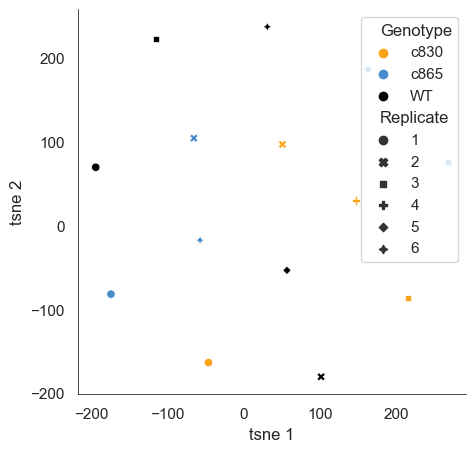

In [10]:
sns.set(font="Arial")
sns.set(font_scale=1)
sns.set_style("white")

fig,ax=plt.subplots(1,1,figsize=(5,5))
sns.despine(right=True, top=True)
sns.scatterplot(data=tsneDf,x='tsne 1',y='tsne 2',hue="Genotype",style="Replicate",ax=ax,palette=["#FAA31B","#488CCB","Black"])
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.5)
plt.savefig('Figure5A_alt', format='pdf',transparent=True)

SyntaxError: unexpected character after line continuation character (904803545.py, line 1)

In [14]:
tpm

gene_name,slc35a5,ccdc80,nrf1,ube2h,nherf1a,dap,ITSN1,MYH10,tmem267,thraa,...,ENSDARG00000117818,ENSDARG00000117819,ENSDARG00000117820,ENSDARG00000117821,ENSDARG00000117822,ENSDARG00000117823,ENSDARG00000117824,ENSDARG00000117825,ENSDARG00000117826,ENSDARG00000117827
asgr1a_c830_1,0.692389,0.140002,3.133084,7.728279,5.796501,84.408105,2.659072,16.294454,0.918648,1.211164,...,0.007497,0.317814,0.037134,0.0,0.299201,0.0,1.227926,0.017054,0.088474,0.016582
asgr1a_c830_2,0.292696,0.295233,3.163907,13.969382,15.649402,53.880377,5.218394,17.894778,1.146858,3.032357,...,0.004095,0.172512,0.034334,0.033734,0.960633,0.0,1.397209,0.054536,0.097173,0.016323
asgr1a_c830_3,1.871737,0.510075,1.894494,12.572097,1.481535,38.909102,2.010783,14.643744,0.972708,3.670518,...,0.005095,0.0,0.0,0.0,0.315618,0.0,1.799969,0.015533,0.0,0.0
asgr1a_c830_4,2.613986,0.276603,3.120321,20.189173,2.921475,251.360085,2.418743,14.328657,1.067635,3.459455,...,0.005427,0.0,0.0,0.0,0.73874,0.0,1.819845,0.0,0.076298,0.0
asgr1a_c865_1,1.516859,2.665059,3.582788,24.830189,11.185988,91.099254,6.292908,4.162569,1.897004,3.931387,...,0.01358,0.222002,0.00938,0.012735,0.888773,0.0,2.375537,0.038833,0.146843,0.056312
asgr1a_c865_2,1.669714,0.867325,3.167617,20.260531,11.461526,65.057005,4.672109,11.972416,1.279978,3.01708,...,0.010814,1.137852,0.017917,0.045003,0.694611,0.0,2.339379,0.074054,0.03801,0.0
asgr1a_c865_3,1.819135,0.354345,3.234556,21.047981,5.575089,131.96473,3.791355,9.133761,0.622793,2.546611,...,0.016883,0.0,0.0,0.0,0.340228,0.0,2.633393,0.0,0.0,0.0
asgr1a_c865_5,1.48048,0.205646,2.686804,13.258926,5.440525,63.371688,3.751435,6.723736,0.68118,3.268387,...,0.0,0.0,0.0,0.0,0.482237,0.0,1.453853,0.0,0.18506,0.0
asgr1a_c865_6,0.403299,0.108963,2.562299,10.073789,11.364751,121.336095,3.764233,7.96946,0.893722,2.198196,...,0.018171,0.0,0.0,0.0,0.45691,0.0,1.180931,0.0,0.0,0.0
nluc_control_1,0.695332,1.139329,3.472788,13.826084,14.962042,63.669009,5.531905,23.610256,1.824808,3.86287,...,0.006575,0.0,0.037586,0.0,0.839529,0.40866,1.985505,0.034523,0.044776,0.083919


In [10]:
genes=["cyp2aa4","lipg","camk2n1a","elmo2","cited4a","rock2b","bcl6aa","ldlra","sult6b1","neu3.3",
                      "ms4a17c.1","gpx1b","fbxo32","sst1.1","sst2","cyp7a1","abcg5","abcg8","abca1a","abca1b","insig1","insig2","cyp8b1.3","cyp27b1","cyp3a65","CYP27A1"]
genes3=["abca1a","abca1b","abcg5","abcg8","bcl6aa"]
genes2=["ldlra","apoea","sst1.1","sst2","ms4a17c.1"]
genes4=["cyp7a1","cyp2aa4","cyp8b1.3","cyp27b1"]
genes_insulin=["elmo2","rock2b","camk2n1a","insrb","insl5a","insl5b","insra","irs2a","igf1","igf2a"]
genes_of_interest=tpm[genes_insulin]

genes_of_interest=genes_of_interest.astype(float)

genes_of_interest

NameError: name 'tpm' is not defined

In [38]:
megadictionary=[]

for index,row in genes_of_interest.iterrows():
    genotype=''
    i=0

    for value in row:

        if 'c830' in index:
            genotype='c830'
            megadictionary.append({"Genotype":"Pooled","Gene":genes_insulin[i],"TPMlog2":np.log2(value+1)})
        elif 'c865' in index:
            genotype='c865'
            megadictionary.append({"Genotype":"Pooled","Gene":genes_insulin[i],"TPMlog2":np.log2(value+1)})
        elif 'nluc' in index:
            genotype='WT'
            megadictionary.append({"Genotype":genotype,"Gene":genes_insulin[i],"TPMlog2":np.log2(value+1)})
        i+=1
asgrrna_seq=pd.DataFrame(megadictionary)

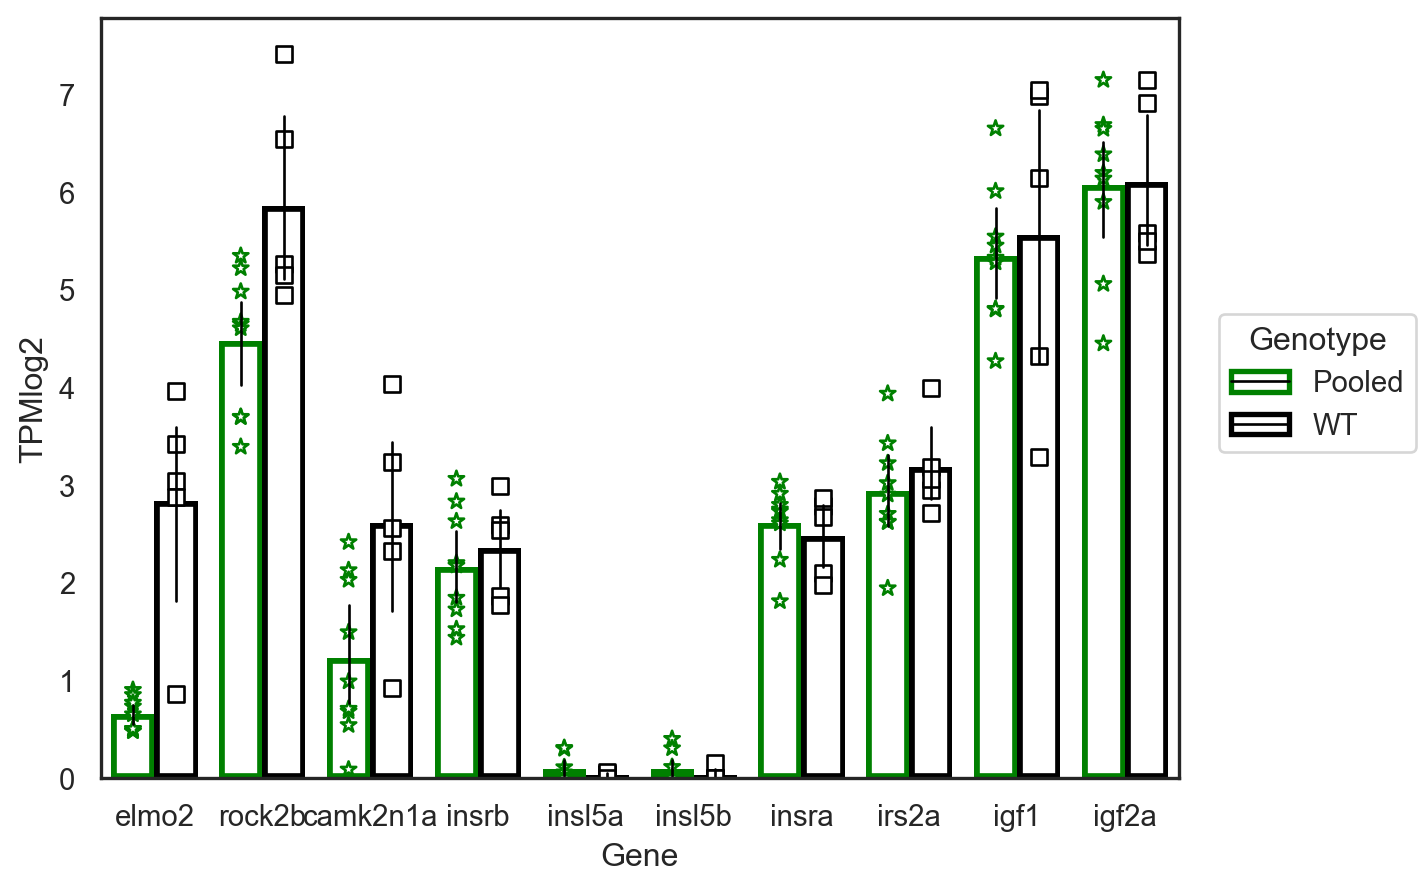

In [39]:

(
    so.Plot(asgrrna_seq.loc[asgrrna_seq["Gene"].isin(genes_insulin)], x="Gene", y="TPMlog2",edgecolor='Genotype')
    .theme({**axes_style("white")})
    .add(so.Bar(color="w",edgewidth=2),so.Agg(),so.Dodge())
    .scale(edgecolor=["Green","Black"])
    .add(so.Range(color="black",linewidth=1), so.Est(), so.Dodge())
    .scale(edgecolor=["Green","Black"])
    .add(so.Dot(color="w",edgewidth=1),so.Dodge(by=["edgecolor"]),marker="Genotype")
    .scale(marker=["*","s"])
    .save('6_3_2024_analysis/temp.pdf', format='pdf',transparent=True)
)


In [15]:
from bioinfokit import analys, visuz
bioinfokit.__version__
import seaborn.objects as so
from seaborn import axes_style

In [21]:
tpm=pd.read_csv("6_3_2024_analysis/salmon.merged.gene_tpm_6_3_24.tsv",index_col=1,sep="\t").T

tpm=tpm.drop("gene_id")
tpm=tpm.astype("float")
tpm=tpm.drop(["asgr1a_c830_5_dif","asgr1a_c830_6_dif","asgr1a_c830_7_dif",
                         "asgr1a_c865_7_dif","asgr1a_c865_8_dif","asgr1a_c865_9_dif",
                         "nluc_control_7_dif","nluc_control_8_dif","nluc_control_9_dif"])


In [22]:
heatmap=tpm.T.corr(method="pearson")
tpm=tpm.astype("float")
heatmap

,asgr1a_c830_1,asgr1a_c830_2,asgr1a_c830_3,asgr1a_c830_4,asgr1a_c865_1,asgr1a_c865_2,asgr1a_c865_3,asgr1a_c865_5,asgr1a_c865_6,nluc_control_1,nluc_control_2,nluc_control_3,nluc_control_5,nluc_control_6
asgr1a_c830_1,1.000000,0.946088,0.774697,0.899221,0.938214,0.931935,0.927306,0.892988,0.937403,0.969413,0.953169,0.950425,0.877185,0.869602
asgr1a_c830_2,0.946088,1.000000,0.797906,0.944879,0.941588,0.901189,0.947520,0.907079,0.962443,0.987461,0.966920,0.985857,0.915115,0.930537
asgr1a_c830_3,0.774697,0.797906,1.000000,0.781785,0.751975,0.778801,0.807036,0.923413,0.827090,0.777793,0.869648,0.779457,0.810375,0.892009
asgr1a_c830_4,0.899221,0.944879,0.781785,1.000000,0.917385,0.864507,0.979970,0.937469,0.975833,0.935064,0.917270,0.965480,0.978549,0.966214
asgr1a_c865_1,0.938214,0.941588,0.751975,0.917385,1.000000,0.916071,0.952933,0.895500,0.952273,0.965799,0.949199,0.933122,0.908125,0.880933
asgr1a_c865_2,0.931935,0.901189,0.778801,0.864507,0.916071,1.000000,0.908484,0.894271,0.914964,0.933497,0.941748,0.916429,0.881843,0.851142
asgr1a_c865_3,0.927306,0.947520,0.807036,0.979970,0.952933,0.908484,1.000000,0.956769,0.991294,0.954484,0.949797,0.960343,0.971487,0.954624
asgr1a_c865_5,0.892988,0.907079,0.923413,0.937469,0.895500,0.894271,0.956769,1.000000,0.953682,0.905044,0.942608,0.917896,0.956019,0.971833
asgr1a_c865_6,0.937403,0.962443,0.827090,0.975833,0.952273,0.914964,0.991294,0.953682,1.000000,0.964563,0.962326,0.968657,0.966600,0.960663
nluc_control_1,0.969413,0.987461,0.777793,0.935064,0.965799,0.933497,0.954484,0.905044,0.964563,1.000000,0.976561,0.982588,0.911641,0.906670


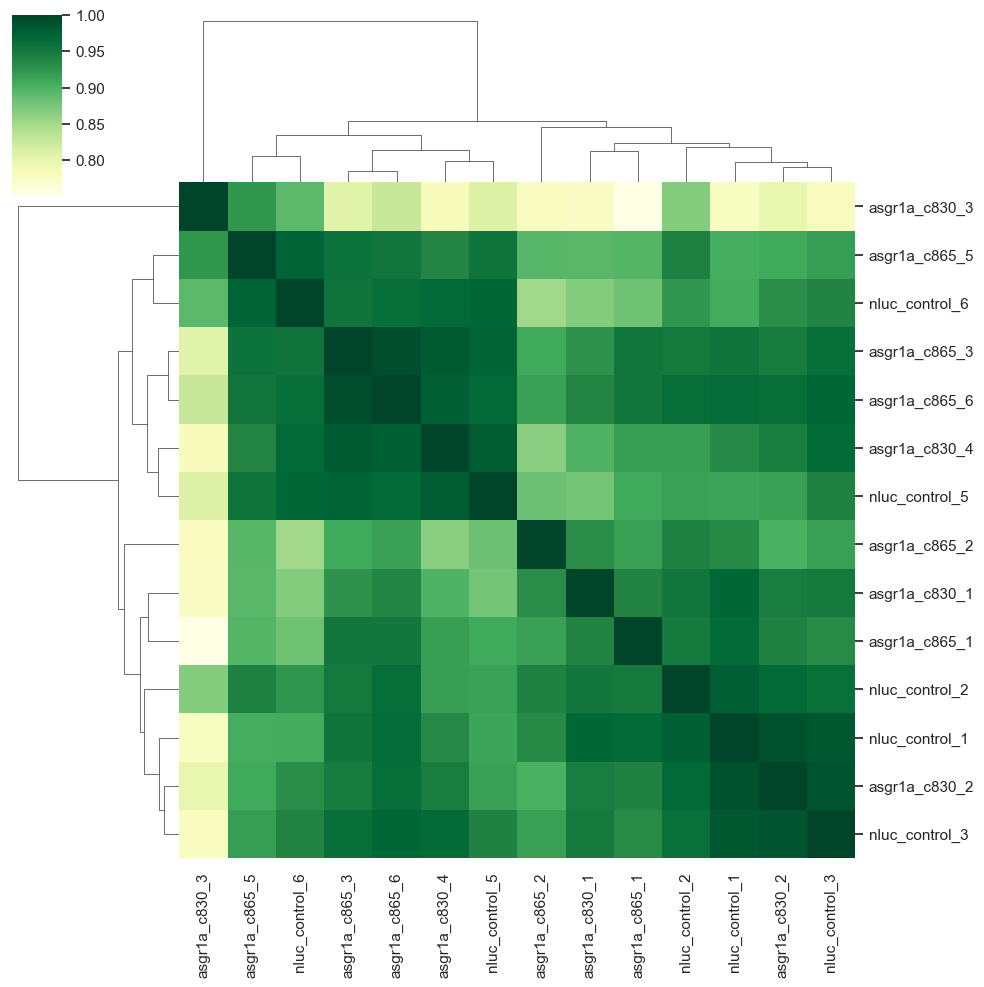

In [23]:
sns.clustermap(data=heatmap,annot=False,cmap="YlGn",annot_kws={"fontsize":15})
plt.savefig('Figure5A_heatmap.pdf', format='pdf',transparent=True)

# Intestine Data 

In [40]:
tpm=pd.read_csv("Intestine/salmon.merged.gene_tpm.tsv",index_col=1,sep='\t').T

tpm=tpm.iloc[1:,]
tpm

gene_name,slc35a5,ccdc80,nrf1,ube2h,nherf1a,dap,ITSN1,MYH10,tmem267,thraa,...,ENSDARG00000117818,ENSDARG00000117819,ENSDARG00000117820,ENSDARG00000117821,ENSDARG00000117822,ENSDARG00000117823,ENSDARG00000117824,ENSDARG00000117825,ENSDARG00000117826,ENSDARG00000117827
c830_int_1,0.660214,0.584221,3.957719,14.762378,175.841911,109.915673,3.573079,7.343011,2.912682,6.463272,...,0.013371,0.160448,0.0,0.0,0.547321,0.0,1.100164,0.0,0.0,0.033919
c830_int_2,0.863879,1.204929,2.840686,11.402235,147.294737,95.926792,3.86152,5.538187,1.940304,6.325814,...,0.044439,0.0,0.0,0.023326,0.752108,0.0,1.906468,0.435366,0.053775,0.0
c830_int_3,0.70043,0.53788,2.920122,15.45843,116.41769,73.775067,4.666933,9.57329,2.034992,6.504834,...,0.070914,0.0,0.016745,0.0,0.414392,0.36627,1.14948,0.0,0.035525,0.022432
c830_int_4,1.387173,0.260128,3.893811,10.352165,106.866733,178.426412,3.015741,5.777929,1.893561,7.926487,...,0.004335,0.0,0.0,0.0,0.714524,0.0,0.676619,0.0,0.0,0.034517
c830_int_5,1.367029,0.783452,3.582403,14.768535,152.254693,458.628556,1.510617,3.380184,1.68681,4.231233,...,0.013049,0.0,0.0,0.0,0.915123,0.0,0.963345,0.477166,0.0,0.0
c865_int_1,0.996328,0.684631,1.980752,11.531283,132.640225,86.756255,3.358789,2.835918,3.606222,3.733052,...,0.036209,0.0,0.013883,0.019113,0.309649,0.0,2.483144,2.199688,0.058906,0.074393
c865_int_2,0.588624,1.012735,2.077547,8.525918,109.009162,103.351448,5.505083,5.812957,3.027766,3.376799,...,0.059477,0.0,0.0,0.02649,0.776806,0.0,2.366114,2.684513,0.0,0.020517
c865_int_3,1.420392,0.758725,4.050125,11.54678,128.018842,183.324707,2.878706,6.29336,2.378124,4.236808,...,0.003615,0.0,0.0,0.0,0.576577,0.0,1.024352,1.254286,0.0,0.0
c865_int_4,1.337958,0.7853,4.253379,16.09291,161.390232,265.247725,2.853612,5.874771,3.57839,4.423942,...,0.061028,0.0,0.0,0.0,1.335206,0.0,1.096978,2.258598,0.0,0.0
control_int_1,1.312414,0.315283,3.15417,13.757426,273.958935,121.197504,4.044411,4.3566,2.493624,7.772069,...,0.061504,0.180244,0.014222,0.0,1.025509,0.0,1.258669,1.450021,0.030172,0.057156


In [41]:
tpm=tpm.astype(float)
#add two columns to cluster samples for PCA 
tpm["Genotype"]=["c830","c830","c830","c830","c830","c865","c865","c865","c865","WT","WT","WT","WT"]
tpm["Replicate"]=[1,2,3,4,5,1,2,3,4,1,2,3,4]

In [42]:
targets=["Replicate", "Genotype"]
#values for analysis are every column EXCEPT Replciate and Genotype 
x = tpm.loc[:,tpm.columns[:-2]].values
#columns on which to perform PCA analysis
y = tpm.loc[:,targets].values
x = StandardScaler().fit_transform(x)

In [43]:
#performs PCA 
pca = PCA(n_components=2)
#isolates pricniple components into a dataframe with sample groups and replicates 
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2'])
principalDf.index = np.arange(1, len(principalDf) + 1)
principalDf["Genotype"]=["c830","c830","c830","c830","c830","c865","c865","c865","c865","WT","WT","WT","WT"]
principalDf["Replicate"]=[1,2,3,4,5,1,2,3,4,1,2,3,4]
#find variance explained by PCA 
pca.explained_variance_ratio_

array([0.12558067, 0.11707918])

In [44]:
from sklearn.manifold import TSNE
tsne = TSNE()
tsne_result = tsne.fit_transform(x)
tsne_result.shape
tsneDf = pd.DataFrame(data = tsne_result
             , columns = ['tsne 1', 'tsne 2'])
tsneDf["Genotype"]=["c830","c830","c830","c830","c830","c865","c865","c865","c865","WT","WT","WT","WT"]
tsneDf["Replicate"]=[1,2,3,4,5,1,2,3,4,1,2,3,4]

/Users/jderrick/opt/anaconda3/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/Users/jderrick/opt/anaconda3/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


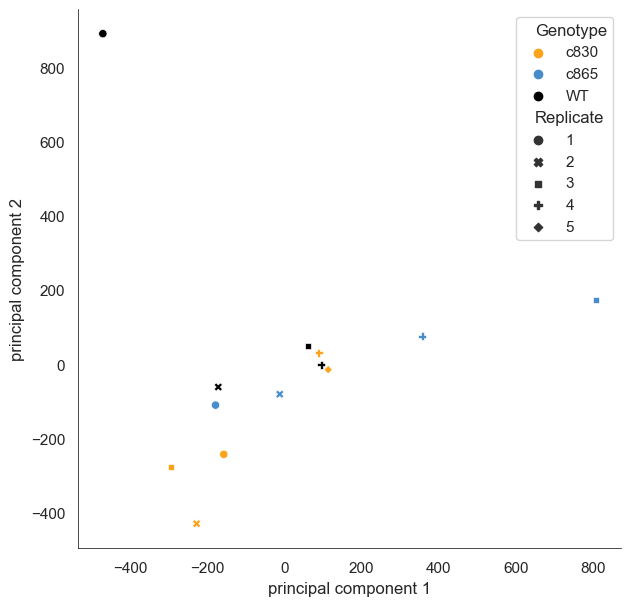

In [46]:
sns.set(font="Arial")
sns.set(font_scale=1)
sns.set_style("white")

fig,ax=plt.subplots(1,1,figsize=(7,7))
sns.despine(right=True, top=True)
sns.scatterplot(data=principalDf,x='principal component 1',y='principal component 2',hue="Genotype",style="Replicate",ax=ax,palette=["#FAA31B","#488CCB","Black"])
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.5)
plt.savefig('Figure5A', format='pdf',transparent=True)

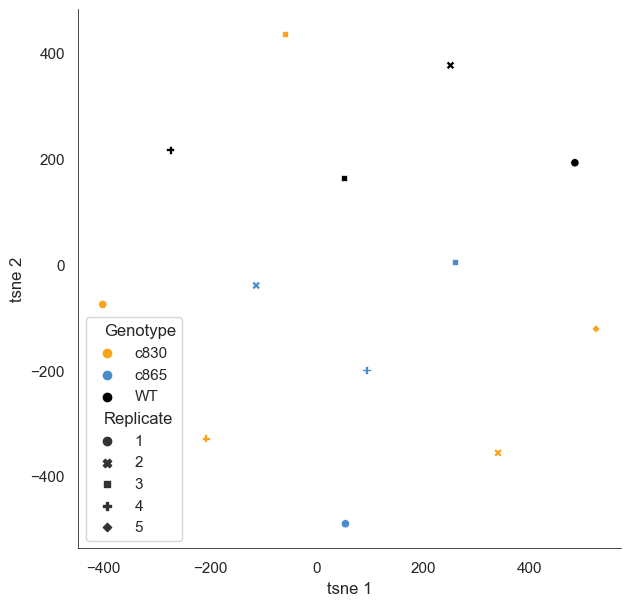

In [48]:
sns.set(font="Arial")
sns.set(font_scale=1)
sns.set_style("white")

fig,ax=plt.subplots(1,1,figsize=(7,7))
sns.despine(right=True, top=True)
sns.scatterplot(data=tsneDf,x='tsne 1',y='tsne 2',hue="Genotype",style="Replicate",ax=ax,palette=["#FAA31B","#488CCB","Black"])
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.5)
plt.savefig('Figure5A_alt', format='pdf',transparent=True)

# T-Test Pathway Analysis

In [100]:
total_genes=pd.read_csv("6_10_2024_analysis/pooled_result.csv")
with open('bile_acid_metabolism_pathways.txt', 'r') as file:
    text = file.read()
gene_list=text.split(",")

with open('TCA_cycle.txt', 'r') as file:
    text = file.read()
tca_list=text.split(",")

In [101]:
bile_only=total_genes[total_genes['gene_id'].isin(gene_list)]
tca = total_genes[total_genes['gene_id'].isin(tca_list)]
print(len(gene_list))

29


In [102]:
bile_only["Pathway"]='Bile'
tca["Pathway"]="TCA"
df2=bile_only.append(tca, ignore_index=True)

/var/folders/6c/5bxs10ps1rgc_ff8r24b_x0c0000gp/T/ipykernel_90012/3798053414.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bile_only["Pathway"]='Bile'
/var/folders/6c/5bxs10ps1rgc_ff8r24b_x0c0000gp/T/ipykernel_90012/3798053414.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tca["Pathway"]="TCA"
/var/folders/6c/5bxs10ps1rgc_ff8r24b_x0c0000gp/T/ipykernel_90012/3798053414.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat i

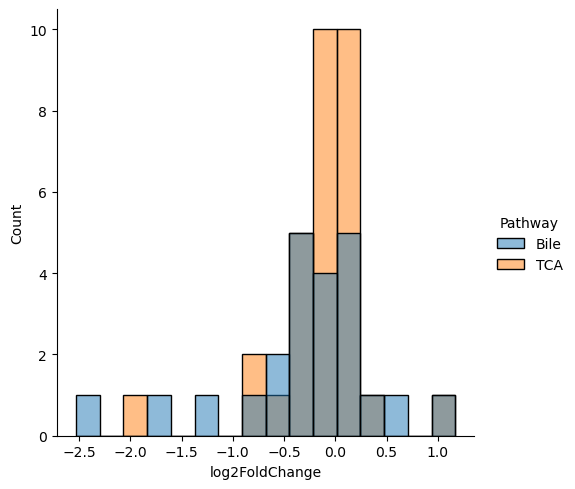

In [103]:
sns.displot(df2,x="log2FoldChange",hue="Pathway")


p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Bile v.s. TCA: t-test independent samples with Bonferroni correction, P_val=3.641e-01 stat=-9.156e-01
-0.3025188693375438 -0.14680509344230191


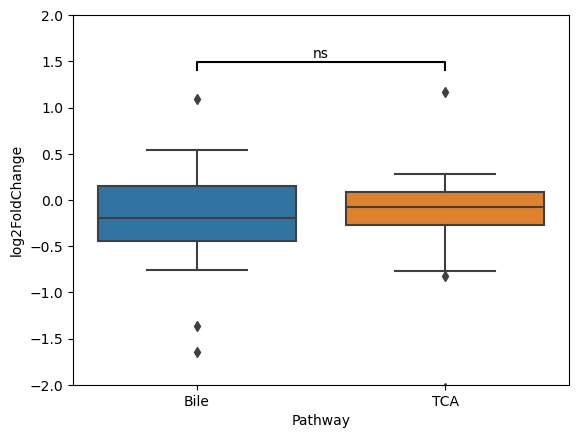

In [106]:
fig,ax=plt.subplots(1,1)
sns.boxplot(df2,x="Pathway",y="log2FoldChange",ax=ax)
ax.set_ylim(-2,2)
box_pairs=[
    
    (("Bile"),("TCA"))

    
]

add_stat_annotation(ax=ax,data=df2, x="Pathway", y='log2FoldChange',
                    box_pairs=box_pairs,
                    test='t-test_ind', text_format='star', loc='inside', verbose=2,color='k')
print(bile_only["log2FoldChange"].mean(),tca["log2FoldChange"].mean())

In [83]:
total_genes=pd.read_csv("Intestine/pooled_result.csv")
with open('TICE_pathways.txt', 'r') as file:
    text = file.read()
gene_list2=text.split(",")


In [64]:
bile_only=total_genes[total_genes['gene_id'].isin(gene_list)]
random_genes = total_genes
bile_only["Pathway"]='TICE'
random_genes["Pathway"]="Random"
df2=bile_only.append(random_genes, ignore_index=True)

/var/folders/6c/5bxs10ps1rgc_ff8r24b_x0c0000gp/T/ipykernel_90012/3023241626.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bile_only["Pathway"]='TICE'
/var/folders/6c/5bxs10ps1rgc_ff8r24b_x0c0000gp/T/ipykernel_90012/3023241626.py:5: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df2=bile_only.append(random_genes, ignore_index=True)


p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

TICE v.s. Random: t-test independent samples with Bonferroni correction, P_val=8.038e-01 stat=2.484e-01
0.09756692825046132 0.06727499252571276


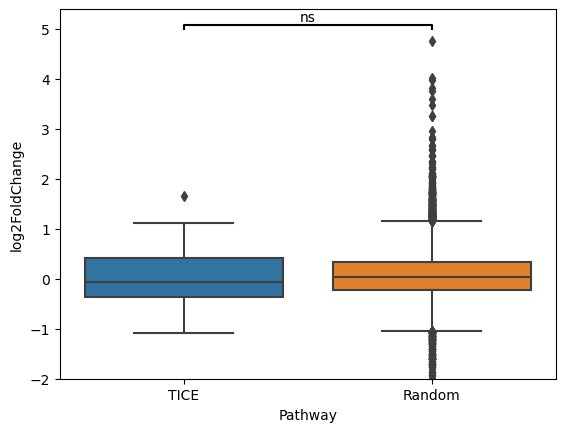

In [65]:
fig,ax=plt.subplots(1,1)
sns.boxplot(df2,x="Pathway",y="log2FoldChange",ax=ax)
ax.set_ylim(-2,2)
box_pairs=[
    
    (("TICE"),("Random"))

    
]

add_stat_annotation(ax=ax,data=df2, x="Pathway", y='log2FoldChange',
                    box_pairs=box_pairs,
                    test='t-test_ind', text_format='star', loc='inside', verbose=2,color='k')
print(bile_only["log2FoldChange"].mean(),total_genes["log2FoldChange"].mean())